In [195]:
## import all the packages
import os
import sqlite3 as sql
import pandas as pd
import numpy as np
import math
import requests
import seaborn as sns
import folium
import folium.plugins
from geopy.geocoders import Nominatim
import time
from IPython.display import display
import matplotlib.pyplot as plt

In [7]:
## import the csv files

## accident
file_path = "/Users/kelliewong/Desktop/college/junior/sta141b/US_Accidents_March23.csv" # replace this by the correct path
if os.path.exists(file_path):
    print("File was found.")
else:
    print("File could not be found. Please change the file_path accordingly.")

## insurance
file_path = "/Users/kelliewong/Desktop/college/junior/sta141b/auto_insurance_cost.csv" # replace this by the correct path
if os.path.exists(file_path):
    print("File was found.")
else:
    print("File could not be found. Please change the file_path accordingly.")

## population
file_path = "/Users/kelliewong/Desktop/college/junior/sta141b/us_pop_by_state.csv" # replace this by the correct path
if os.path.exists(file_path):
    print("File was found.")
else:
    print("File could not be found. Please change the file_path accordingly.")

df_orig = pd.read_csv("/Users/kelliewong/Desktop/college/junior/sta141b/US_Accidents_March23.csv")
df_insur = pd.read_csv("/Users/kelliewong/Desktop/college/junior/sta141b/auto_insurance_cost.csv")
df_pop = pd.read_csv("/Users/kelliewong/Desktop/college/junior/sta141b/us_pop_by_state.csv")

File was found.
File was found.
File was found.


In [209]:
## merged accidents and population: https://www.kaggle.com/datasets/alexandrepetit881234/us-population-by-state
state_counts = (df_orig["State"].value_counts().rename_axis("State_Code").reset_index(name="Accident_Count"))  ## count the accidents by state
population = df_pop.rename(columns={"state_code": "State_Code"})  ## renaming the columns to match up
accident_pop = pd.merge(state_counts, population, on="State_Code")  ## joining
accident_pop["Accidents_Ratio"] = accident_pop["Accident_Count"] / accident_pop["2020_census"]  ## ratio of accidents per person per state
accident_pop = accident_pop[["State_Code", "state", "Accident_Count", "2020_census", "Accidents_Ratio"]]  ## new data
insurance = df_insur[["state", "full_coverage"]]  ## getting the columns from insurance
all_df = pd.merge(accident_pop, insurance, on="state")  ## merger the data all together
all_df.rename(columns={"full_coverage": "Full_Coverage"}, inplace=True)  ## renaming the column to look more cohesive
all_df_sort = all_df.sort_values("state").reset_index(drop=True)  ## sort by the states

In [211]:
corr = all_df_sort["Accidents_Ratio"].corr(all_df_sort["Full_Coverage"])
print(corr)  ## correlation, not great

0.037954597254158


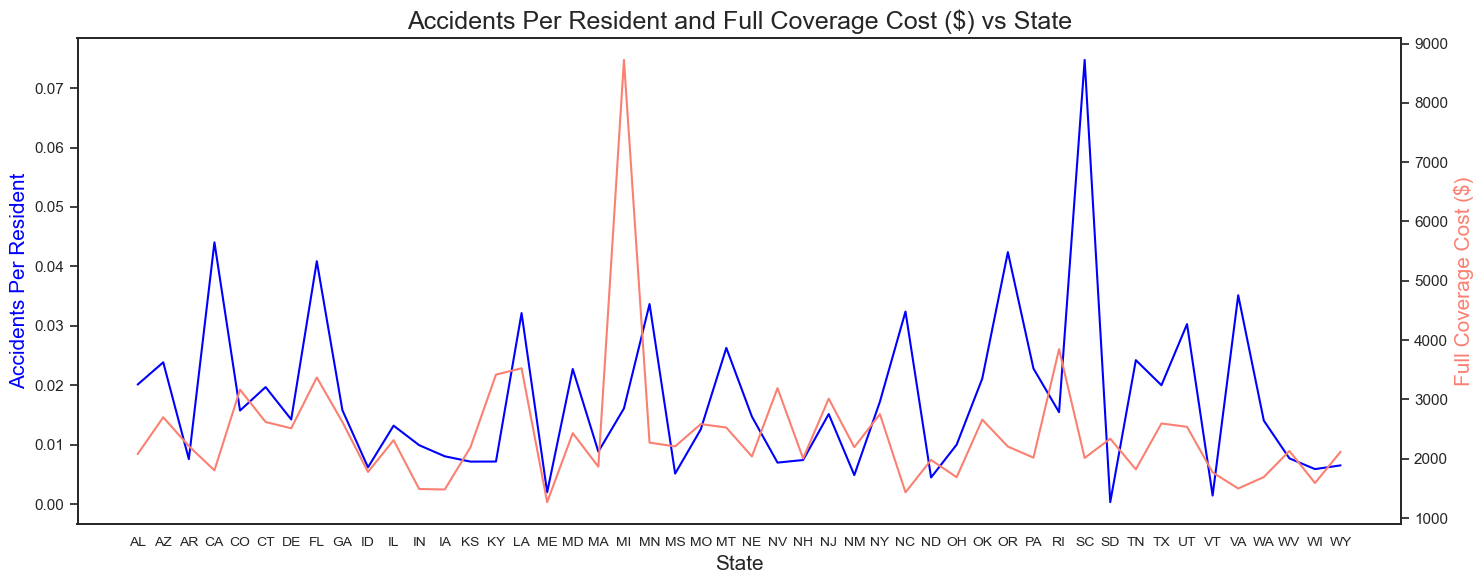

In [215]:
## seaborn graph
sns.set_theme(style="white")  ## white background
fig, ax1 = plt.subplots(figsize=(15,6))  ## size of the plot
sns.lineplot(data=all_df_sort,
             x = "State_Code",
             y = "Accidents_Ratio",
             color = "blue",
             ax=ax1)
ax1.set_ylabel("Accidents Per Resident", color = "blue", size = 15)  ## color coding it with the line color
ax1.tick_params(axis="y")  ## specified the measurements
ax1.tick_params(axis="x", labelsize = 10)  ## changed the size of x axis labels
ax2 = ax1.twinx()  ## double up on the lines
sns.lineplot(data=all_df_sort,
             x = "State_Code",
             y = "Full_Coverage",
             color = "salmon",
             ax=ax2)
ax2.set_ylabel("Full Coverage Cost ($)", color = "salmon", size = 15)  ## color coding with the line
ax2.tick_params(axis="y")  ## specified measurements
ax2.set_title("Accidents Per Resident and Full Coverage Cost ($) vs State", size=18)  ## title
ax1.set_xlabel("State", fontsize = 15)  ## changed the x axis label font size
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [217]:
## plot for 2020
df_orig["Start_Time"] = pd.to_datetime(df_orig["Start_Time"], format="ISO8601")  ## getting the year again, making into datetime
df_orig["Year"] = df_orig["Start_Time"].dt.year  ## getting the year
df2020 = df_orig[df_orig["Year"] == 2020]  ## filtering for 2020
state_counts_2020 = (df2020["State"].value_counts().rename_axis("State_Code").reset_index(name="Accident_Count_2020"))  ## count per state
accident_pop_2020 = pd.merge(state_counts_2020, population, on="State_Code")  ## merge the data
accident_pop_2020["Accidents_Ratio"] = accident_pop_2020["Accident_Count_2020"] / accident_pop_2020["2020_census"]  ## getting the ratio
accident_pop_2020 = accident_pop_2020[["State_Code", "state", "Accident_Count_2020", "2020_census", "Accidents_Ratio"]]  ## getting the columns
all_df_2020 = pd.merge(accident_pop_2020, insurance, on="state")  ## merging the insurance data
all_df_2020.rename(columns={"full_coverage": "Full_Coverage"}, inplace=True)  ## cohesive column names
all_df_sort_2020 = all_df_2020.sort_values("state").reset_index(drop=True)  ## sorting by state

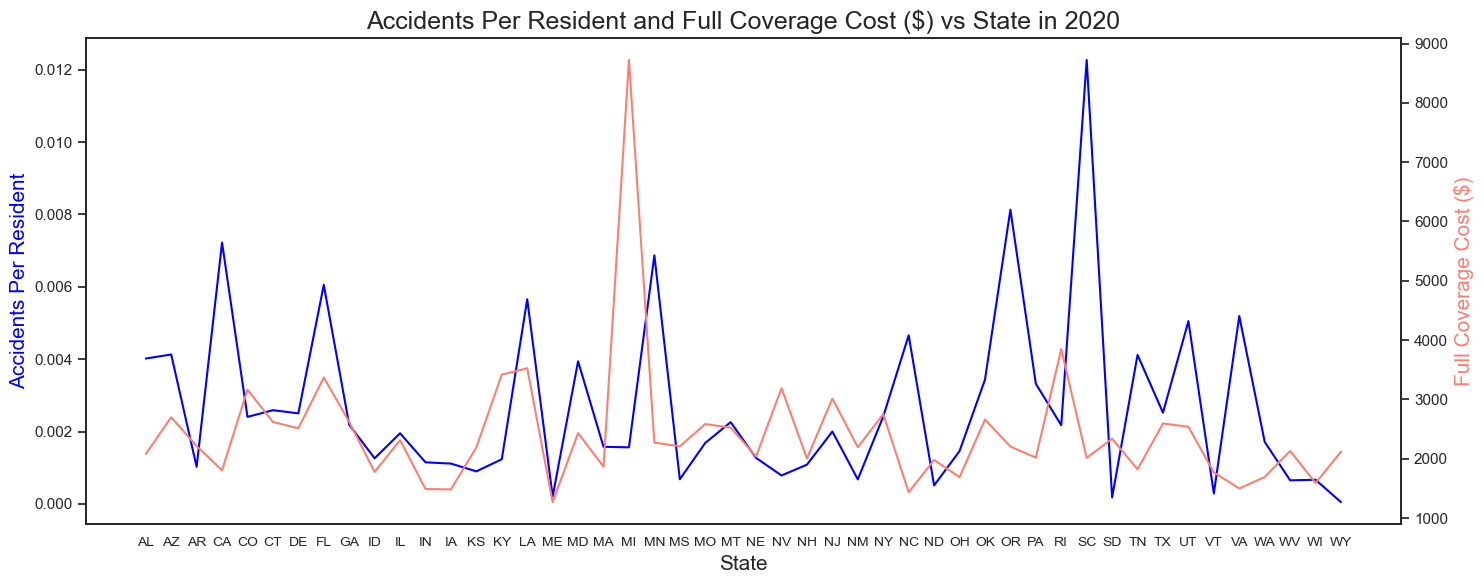

In [218]:
## seaborn graph
sns.set_theme(style="white")  ## white background
fig, ax1 = plt.subplots(figsize=(15,6))  ## size of the plot
sns.lineplot(data=all_df_sort_2020,
             x = "State_Code",
             y = "Accidents_Ratio",
             color = "blue",
             ax=ax1)
ax1.set_ylabel("Accidents Per Resident", color = "blue", size = 15)  ## color coding it with the line color
ax1.tick_params(axis="y")  ## specified the measurements
ax1.tick_params(axis="x", labelsize = 10)  ## changed the size of x axis labels
ax2 = ax1.twinx()  ## double up on the lines
sns.lineplot(data=all_df_sort,
             x = "State_Code",
             y = "Full_Coverage",
             color = "salmon",
             ax=ax2)
ax2.set_ylabel("Full Coverage Cost ($)", color = "salmon", size = 15)  ## color coding with the line
ax2.tick_params(axis="y")  ## specified measurements
ax2.set_title("Accidents Per Resident and Full Coverage Cost ($) vs State in 2020", size=18)  ## title
ax1.set_xlabel("State", fontsize = 15)  ## changed the x axis label font size
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [221]:
corr = all_df_sort_2020["Accidents_Ratio"].corr(all_df_sort_2020["Full_Coverage"])
print(corr)  ## correlation

-0.009096658125950967


In [223]:
## temp and accident
df_temp = df_orig[["Temperature(F)"]].copy()  ## made a copy of the data
df_temp = df_temp.dropna(subset=["Temperature(F)"])  ## dropped blanks
temp99 = df_temp["Temperature(F)"].quantile(0.99)  ## got the 99 quantile to account for outliers
df_temp = df_temp[df_temp["Temperature(F)"] <= temp99] ## cleaned data, ready for use
df_temp["Temp_bin"] = pd.cut(df_temp["Temperature(F)"], bins=np.arange(-20, 120, 5))  ## clumped the data to make it easier to scatter and see, too many points
temp_counts = df_temp.groupby("Temp_bin").size().reset_index(name="Accident_Count")  ## group by the cutoffs
temp_counts["Temp_Mid"] = temp_counts["Temp_bin"].apply(lambda x: x.mid).astype(float) ## find the middle point in the subgroups
x = temp_counts["Temp_Mid"].values  ## set that as the x
y = temp_counts["Accident_Count"].values  ## set the number of accidents as y
xmean = np.mean(x)  ## get the means
ymean = np.mean(y)
numer = np.sum((x-xmean)*(y-ymean))  ## numerator for regression
denom = np.sum((x-xmean)**2)  ## denominator for regression
b1 = numer/denom  ## find our slope
b0 = ymean - b1 * xmean  ## y intercept
y_reg = b1 * x + b0  ## linear regression line

/var/folders/gs/ls5swb2s795dnfcgpfgkpgyc0000gn/T/ipykernel_92823/1035004120.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp_counts = df_temp.groupby("Temp_bin").size().reset_index(name="Accident_Count")  ## group by the cutoffs


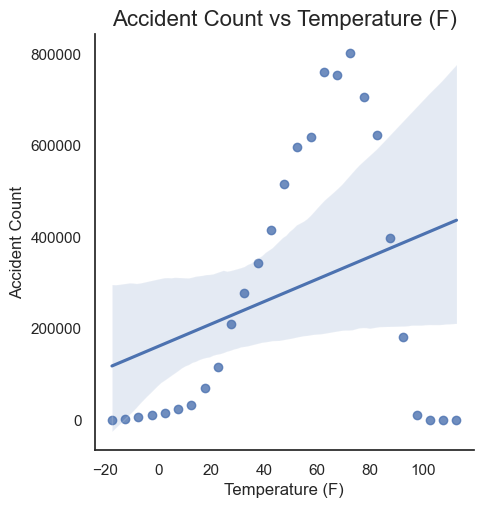

In [227]:
sns.set_theme(style="white")  ## white background
sns.lmplot(data=temp_counts,  ## linear regression plot
            x = "Temp_Mid",
            y = "Accident_Count",
            scatter=True)
plt.xlabel("Temperature (F)", fontsize=12)  ## labels the axis
plt.ylabel("Accident Count", fontsize=12)
plt.title("Accident Count vs Temperature (F)", fontsize = 16)  ## title
plt.show()  ## print it out

In [229]:
## calculating r^2
ssr = np.sum((y-y_reg)**2)
sst = np.sum((y-ymean)**2)
r2 = 1 - ssr/sst
print(r2)

0.11051138353307521


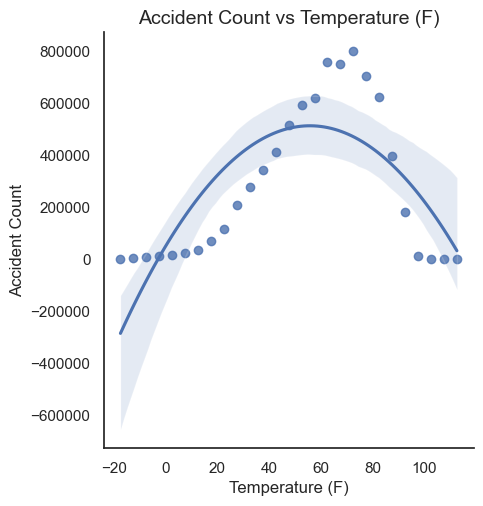

In [231]:
sns.set_theme(style="white")  ## white background
sns.lmplot(data=temp_counts, x="Temp_Mid",  ## polynomial regression
            y="Accident_Count",
            order=2,  ## specifies that i want a polynomial
            scatter=True)
plt.xlabel("Temperature (F)", fontsize=12)  ## labeled axis
plt.ylabel("Accident Count", fontsize=12)
plt.title("Accident Count vs Temperature (F)", fontsize = 14)  ## title
plt.show()

In [233]:
coeff = np.polyfit(x, y, 2)
poly = np.poly1d(coeff)
ypoly = poly(x)
## get the coefficients for the polynomial

In [235]:
## getting the r^2 for the polynomial
ybar = np.mean(y)
ssr = np.sum((y-ypoly)**2)
sst =  np.sum((y-ybar)**2)
r2 = 1-ssr/sst
print(r2)

0.6064000077456693


In [237]:
## precp and accident
df_prec = df_orig[["Precipitation(in)"]].copy()  ## copies the precipitation info
df_prec = df_prec.dropna(subset=["Precipitation(in)"])  ## drops the na values
prec99 = df_prec["Precipitation(in)"].quantile(0.99)  ## 99th quantile
df_prec = df_prec[df_prec["Precipitation(in)"] <= prec99]  ## filters it out
bins = list(np.arange(0, 1.0, 0.05)) + list(np.arange(1.0, prec99 + 0.1, 0.1))  ## groups the data
df_prec["Prec_bin"] = pd.cut(df_prec["Precipitation(in)"], bins=bins)
prec_counts = df_prec.groupby("Prec_bin").size().reset_index(name="Accident_Count")
prec_counts["Prec_Mid"] = prec_counts["Prec_bin"].apply(lambda x: x.mid).astype(float)  ## gets the middle values
x = prec_counts["Prec_Mid"].values  ## sets the x values based on the middles
y = prec_counts["Accident_Count"].values  ## sets y vals
xmean = np.mean(x)  ## mean of x
ymean = np.mean(y)  ## mean of y
numer = np.sum((x-xmean)*(y-ymean))  ## numerator for correlation
denom = np.sum((x-xmean)**2)  ## denominator for correlation
b1 = numer/denom  ## solving for the slope
b0 = ymean - b1 * xmean  ## solving for y intercept
y_reg = b1 * x + b0  ## regression line

/var/folders/gs/ls5swb2s795dnfcgpfgkpgyc0000gn/T/ipykernel_92823/3209303568.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prec_counts = df_prec.groupby("Prec_bin").size().reset_index(name="Accident_Count")


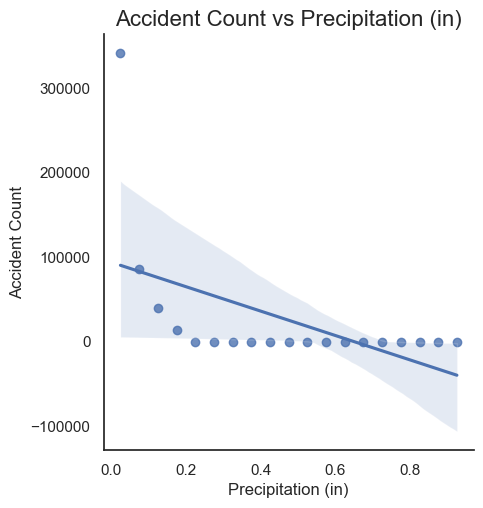

In [239]:
sns.set_theme(style="white")  ## white background
sns.lmplot(data=prec_counts,  ## linear regression line
            x = "Prec_Mid",
            y = "Accident_Count",
            scatter=True)
plt.xlabel("Precipitation (in)", fontsize=12)  ## labels x and y
plt.ylabel("Accident Count", fontsize=12)
plt.title("Accident Count vs Precipitation (in)", fontsize = 16)  ## title
plt.show()

In [241]:
## solving for r^2
ssr = np.sum((y-y_reg)**2)
sst = np.sum((y-ymean)**2)
r2 = 1 - ssr/sst
print(r2)

0.26220722202068536


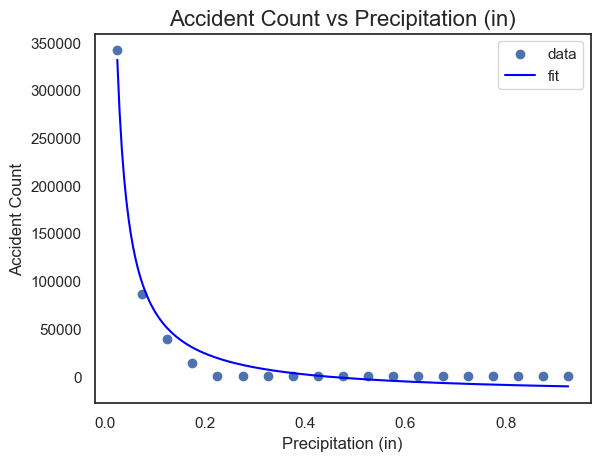

In [243]:
## reciprocal regression, did not use seaborn, used matplotlib because seaborn doesn't have reciprocal function
X = 1/x
coeff = np.polyfit(X, y, 1)  ## get the coefficients
a = coeff[0]
b = coeff[1]
ypred = a*(1/x) + b  ## regression function
xsmooth = np.linspace(min(x), max(x), 200)
ysmooth = a*(1/xsmooth) + b
plt.scatter(x, y, label = "data")  ## scatterplot of the data
plt.plot(xsmooth, ysmooth, color="blue", label="fit")  ## plot the smoothed data
plt.legend()  ## add a legend
plt.xlabel("Precipitation (in)")  ## label axis
plt.ylabel("Accident Count")
plt.title("Accident Count vs Precipitation (in)", fontsize = 16)  ## title
plt.show()

In [245]:
## R^2
ybar = np.mean(y)
ssr = np.sum((y-ypred)**2)
sst =  np.sum((y-ybar)**2)
r2 = 1-ssr/sst
print(r2)

0.9847675222254673


In [247]:
## wind mph and accident
df_wind = df_orig[["Wind_Speed(mph)"]].copy()  ## copied the data
df_wind = df_wind.dropna(subset=["Wind_Speed(mph)"])  ## dropped the na values
wind99 = df_wind["Wind_Speed(mph)"].quantile(0.99)  ## 99 quantile
df_wind = df_wind[df_wind["Wind_Speed(mph)"] <= wind99]  ## filtered and grouped the data
bins = list(np.arange(0, 20, 2)) + list(np.arange(20, wind99 + 2, 5))
df_wind["Wind_bin"] = pd.cut(df_wind["Wind_Speed(mph)"], bins=bins)
wind_counts = df_wind.groupby("Wind_bin").size().reset_index(name="Accident_Count")
wind_counts["Wind_Mid"] = wind_counts["Wind_bin"].apply(lambda x: x.mid).astype(float)  ## middle points
x = wind_counts["Wind_Mid"].values  ## set x values
y = wind_counts["Accident_Count"].values  ## set y values
xmean = np.mean(x)  ## got mean of x
ymean = np.mean(y)  ## got mean of y
numer = np.sum((x-xmean)*(y-ymean))  ## got the numerator for the regression
denom = np.sum((x-xmean)**2)  ## got the denominator for the regression
b1 = numer/denom  ## slope
b0 = ymean - b1 * xmean  ## y intercept
y_reg = b1 * x + b0  ## regression line

/var/folders/gs/ls5swb2s795dnfcgpfgkpgyc0000gn/T/ipykernel_92823/8928630.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wind_counts = df_wind.groupby("Wind_bin").size().reset_index(name="Accident_Count")


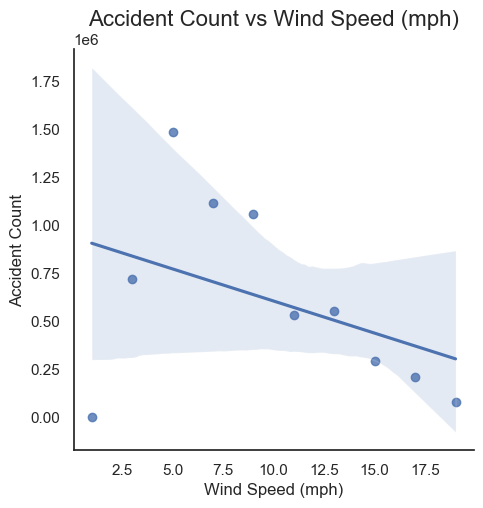

In [249]:
sns.set_theme(style="white")  ## white background
sns.lmplot(data=wind_counts,  ## linear regression
            x = "Wind_Mid",
            y = "Accident_Count",
            scatter=True)
plt.xlabel("Wind Speed (mph)", fontsize=12)  ## labeled axis
plt.ylabel("Accident Count", fontsize=12)
plt.title("Accident Count vs Wind Speed (mph)", fontsize = 16)  ## title
plt.show()

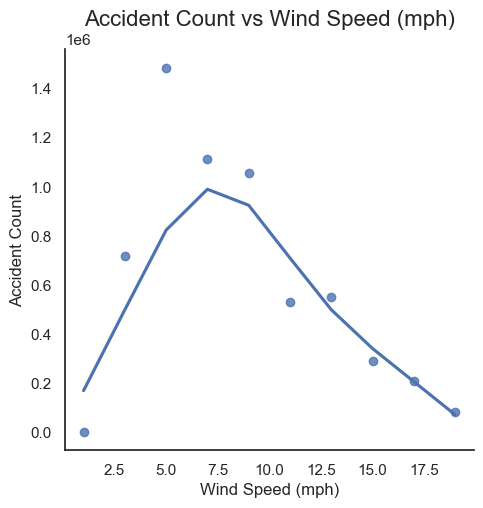

In [251]:
wind_counts["Wind_Mid_Abs"] = np.abs(wind_counts["Wind_Mid"])  ## tried fitting with absolute value parent function
sns.lmplot(data=wind_counts,  ## regression plot
            x="Wind_Mid_Abs",
            y="Accident_Count",
            lowess=True,
            scatter=True)
plt.xlabel("Wind Speed (mph)", fontsize=12)  ## labeled axis
plt.ylabel("Accident Count", fontsize=12)
plt.title("Accident Count vs Wind Speed (mph)", fontsize = 16)  ## title
plt.show()

In [253]:
## R^2
ssr = np.sum((y-y_reg)**2)
sst = np.sum((y-ymean)**2)
r2 = 1 - ssr/sst
print(r2)

0.17111277267246028


In [255]:
## humidity and accidents
df_hum = df_orig[["Humidity(%)"]].copy()  ## copy of the data
df_hum = df_hum.dropna(subset=["Humidity(%)"])  ## dropped na values
hum99 = df_hum["Humidity(%)"].quantile(0.99)  ## 99 quantile
df_hum = df_hum[df_hum["Humidity(%)"] <= hum99]  ## filtered and grouped
bins = np.arange(0, hum99 + 5, 5)
df_hum["Hum_bin"] = pd.cut(df_hum["Humidity(%)"], bins=bins)
hum_counts = df_hum.groupby("Hum_bin").size().reset_index(name="Accident_Count")
hum_counts["Hum_Mid"] = hum_counts["Hum_bin"].apply(lambda x: x.mid).astype(float)  ## middle values
x = hum_counts["Hum_Mid"].values  ## x values
y = hum_counts["Accident_Count"].values  ## y values
xmean = np.mean(x)  ## mean of x
ymean = np.mean(y)  ## mean of y
numer = np.sum((x-xmean)*(y-ymean))  ## numerator for the correlation
denom = np.sum((x-xmean)**2)  ## denominator for the correlation
b1 = numer/denom  ## slope
b0 = ymean - b1 * xmean  ## y intercept
y_reg = b1 * x + b0  ## regression line

/var/folders/gs/ls5swb2s795dnfcgpfgkpgyc0000gn/T/ipykernel_92823/2351227563.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hum_counts = df_hum.groupby("Hum_bin").size().reset_index(name="Accident_Count")


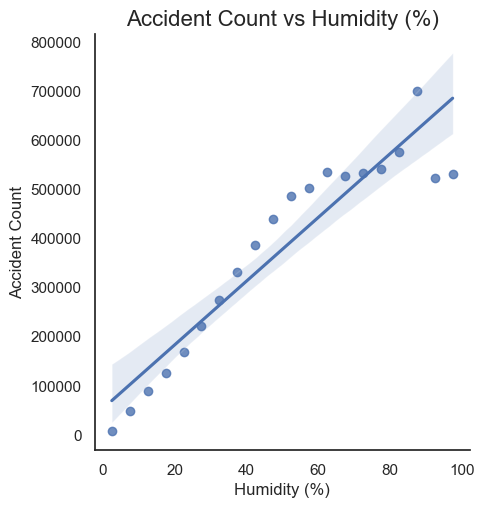

In [257]:
sns.set_theme(style="white")  ## white background
sns.lmplot(data=hum_counts,  ## linear regresssion plot
            x = "Hum_Mid",
            y = "Accident_Count",
            scatter=True)
plt.xlabel("Humidity (%)", fontsize=12)  ## labels
plt.ylabel("Accident Count", fontsize=12)
plt.title("Accident Count vs Humidity (%)", fontsize = 16) ## title
plt.show()

In [259]:
## R^2
ssr = np.sum((y-y_reg)**2)
sst = np.sum((y-ymean)**2)
r2 = 1 - ssr/sst
print(r2)

0.884530916252315


In [ ]:
## extra, preseaborn, can ignore if you want to:
## population and ratio
plt.figure(figsize=(15,6))
fig, ax1 = plt.subplots(figsize=(15,6))
ax1.plot(all_df_sort["State_Code"], all_df_sort["Accidents_Ratio"], color = "blue", marker="o", label = "Accident Ratio")
ax1.set_ylabel("Accidents Per Resident", color = "blue")
ax1.tick_params(axis="y")
ax2 = ax1.twinx()
ax2.plot(all_df_sort["State_Code"], all_df_sort["Full_Coverage"], color = "salmon", marker="o", label = "Full Coverage")
ax2.set_ylabel("Full Coverage Cost ($)", color = "salmon")
ax2.tick_params(axis="y")
plt.xlabel("State")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show() 

## 2020
plt.figure(figsize=(15,6))
fig, ax1 = plt.subplots(figsize=(15,6))
ax1.plot(all_df_sort_2020["State_Code"], all_df_sort_2020["Accidents_Ratio"], color = "blue", marker="o", label = "Accident Ratio")
ax1.set_ylabel("Accidents Per Resident", color = "blue")
ax1.tick_params(axis="y")
ax2 = ax1.twinx()
ax2.plot(all_df_sort_2020["State_Code"], all_df_sort_2020["Full_Coverage"], color = "salmon", marker="o", label = "Full Coverage")
ax2.set_ylabel("Full Coverage Cost ($)", color = "salmon")
ax2.tick_params(axis="y")
plt.xlabel("State")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## temp
## it went somewhere but lowkey irrelvant

## temp poly
plt.scatter(x, y, label="Data")
x_smooth = np.linspace(min(x), max(x), 200)
y_smooth = poly(x_smooth)
plt.plot(x_smooth, y_smooth, color="blue", label="poly fit")
plt.legend()
plt.xlabel("Temperature (F)")
plt.ylabel("Accident Count")
plt.show()

## prec
plt.scatter(x, y, alpha=0.5)
plt.plot(x, y_reg, color="blue")
plt.xlabel("Precipitation (in)")
plt.ylabel("Accident Count")
plt.show()

## prec recip
## stay the same

## wind
plt.scatter(x, y, alpha=0.5)
plt.plot(x, y_reg, color="blue")
plt.xlabel("Wind Speed (mph)")
plt.ylabel("Accident Count")
plt.show()

## humidity
plt.scatter(x, y, alpha=0.5)
plt.plot(x, y_reg, color="blue")
plt.xlabel("Humdity (%)")
plt.ylabel("Accident Count")
plt.show()
